# 📊 EDA — Reviews da Play Store

**CRISP-DM: fases 1-2 (Business & Data Understanding)**

Objetivo: entender a estrutura, volume, distribuição de sentimentos, tamanho dos textos, versões do app e padrões temporais dos reviews coletados.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.db.database import get_engine

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Carregar dados

In [2]:
# Opção A: do banco
try:
    engine = get_engine()
    df = pd.read_sql('SELECT * FROM reviews', engine, parse_dates=['created_at','collected_at'])
except Exception as e:
    print('DB indisponível, carregando CSV:', e)
    from pathlib import Path
    csvs = sorted(Path('../data/raw').glob('reviews_*.csv'))
    df = pd.read_csv(csvs[-1], parse_dates=['created_at','collected_at'])

print(f'Total: {len(df):,} reviews')
df.head()

DB indisponível, carregando CSV: (psycopg2.OperationalError) could not translate host name "db" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)
Total: 3,000 reviews


,review_id,user_name,text,rating,created_at,app_version,thumbs_up,app_id,collected_at,sentiment
0,f36da11d-7122-4c93-af8a-9124dabfadbd,Um usuário do Google,Sérgio neves selox,5,2026-09-21 17:16:49,2.26.17.72,0,com.whatsapp,2026-09-22 17:18:19.762179,POSITIVO
1,015f8cd1-6d8f-43d1-98f6-bbec99fe46c7,Um usuário do Google,Preciso retomar minha conta porque foi desativ...,4,2026-09-21 17:16:17,NaN,0,com.whatsapp,2026-09-22 17:18:19.762179,POSITIVO
2,16719f79-6da1-453b-a04e-ecea7bf3feda,Um usuário do Google,PRECISO MANTER O WHATSAPP MESSENGER PARA QUE E...,3,2026-09-21 17:15:50,2.26.36.74,13,com.whatsapp,2026-09-22 17:18:19.762179,NEUTRO
3,23f5e5b9-cd9b-41e5-a92f-03f67c876415,Um usuário do Google,é um aplicativo muito bom,4,2026-09-21 17:14:51,2.26.12.72,0,com.whatsapp,2026-09-22 17:18:19.762179,POSITIVO
4,d3a656c9-87f1-44d5-a596-45dc33686d51,Um usuário do Google,melhor aplicativo e muito importante .na vida ...,5,2026-09-21 17:14:43,2.26.36.74,0,com.whatsapp,2026-09-22 17:18:19.762179,POSITIVO


## 2. Qualidade dos dados

In [3]:
print('Missing values por coluna:')
print(df.isna().sum())
print(f'\nDuplicatas por review_id: {df.duplicated(subset=["review_id"]).sum()}')
print(f'Reviews com texto vazio: {(df["text"].str.strip() == "").sum()}')

Missing values por coluna:
review_id         0
user_name         0
text              0
rating            0
created_at        0
app_version     344
thumbs_up         0
app_id            0
collected_at      0
sentiment         0
dtype: int64

Duplicatas por review_id: 0
Reviews com texto vazio: 0


## 3. Distribuição de sentimentos

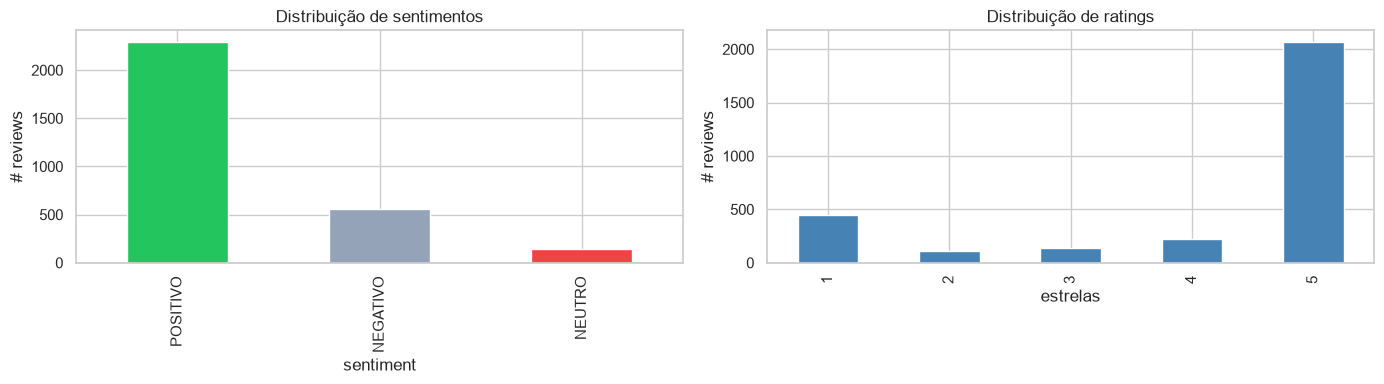


Proporção de classes:
sentiment
POSITIVO    76.6%
NEGATIVO    18.7%
NEUTRO       4.7%
Name: proportion, dtype: str


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=ax1, color=['#22c55e', '#94a3b8', '#ef4444'])
ax1.set_title('Distribuição de sentimentos')
ax1.set_ylabel('# reviews')

df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Distribuição de ratings')
ax2.set_xlabel('estrelas'); ax2.set_ylabel('# reviews')

plt.tight_layout(); plt.show()

print('\nProporção de classes:')
print((df['sentiment'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

## 4. Tamanho dos textos

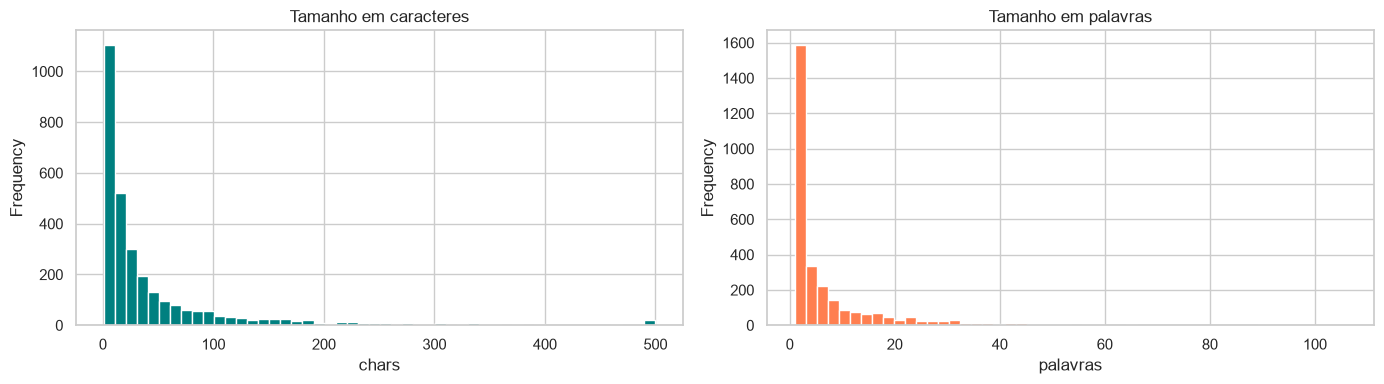

       n_chars  n_words
count   3000.0   3000.0
mean      48.6      8.8
std       79.6     14.2
min        1.0      1.0
25%        8.0      1.0
50%       18.0      3.0
75%       50.0      9.0
max      500.0    106.0


In [5]:
df['n_chars'] = df['text'].str.len()
df['n_words'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['n_chars'].plot(kind='hist', bins=50, ax=axes[0], color='teal')
axes[0].set_title('Tamanho em caracteres'); axes[0].set_xlabel('chars')
df['n_words'].plot(kind='hist', bins=50, ax=axes[1], color='coral')
axes[1].set_title('Tamanho em palavras'); axes[1].set_xlabel('palavras')
plt.tight_layout(); plt.show()

print(df[['n_chars', 'n_words']].describe().round(1))

## 5. Evolução temporal

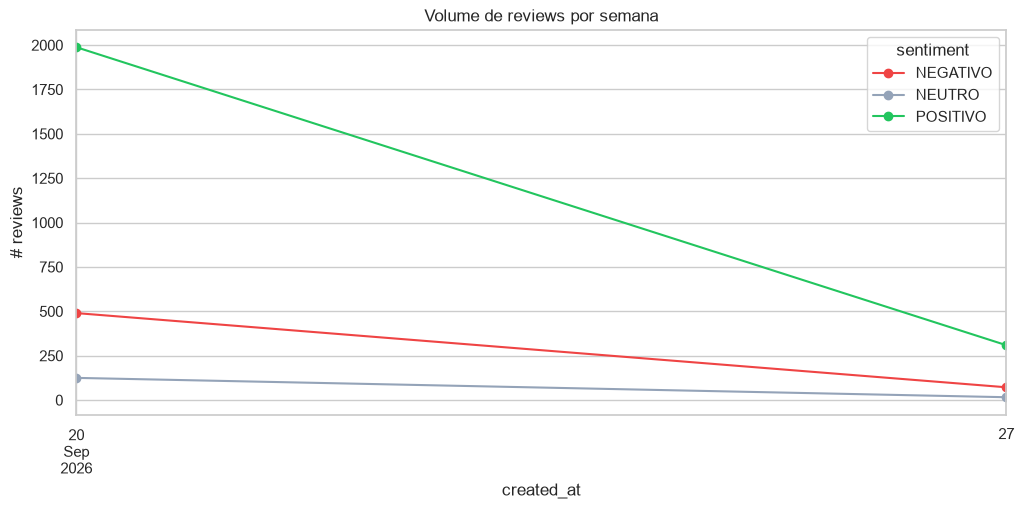

In [6]:
if df['created_at'].notna().any():
    ts = df.set_index('created_at').groupby([pd.Grouper(freq='W'), 'sentiment']).size().unstack(fill_value=0)
    ts.plot(kind='line', color=['#ef4444', '#94a3b8', '#22c55e'], marker='o')
    plt.title('Volume de reviews por semana'); plt.ylabel('# reviews'); plt.show()

## 6. Termos mais frequentes por classe

In [7]:
from collections import Counter
from src.data.preprocess import tokenize

for sent in ['POSITIVO', 'NEGATIVO']:
    subset = df[df['sentiment'] == sent]['text'].dropna()
    counter = Counter()
    for t in subset.head(3000):
        counter.update(tokenize(t))
    top = pd.DataFrame(counter.most_common(20), columns=['termo', 'freq'])
    print(f'\n=== TOP 20 em {sent} ===')
    print(top.to_string(index=False))


=== TOP 20 em POSITIVO ===
     termo  freq
       bom   612
       nao   271
     otimo   222
  whatsapp   176
       app   149
aplicativo   147
       boa   144
 excelente    91
       pra    76
    melhor    69
    gostei    61
      tudo    48
     quero    48
     gosto    47
     otima    44
     legal    40
      usar    38
       dia    38
    porque    37
     ajuda    37

=== TOP 20 em NEGATIVO ===
      termo  freq
        nao   364
   whatsapp   180
        app    79
    consigo    66
      conta    63
 aplicativo    54
        pra    53
       nada    50
     porque    45
     sempre    37
      agora    36
   mensagem    36
    oficial    35
        bom    34
atualizacao    32
     numero    32
       fica    30
       tudo    30
       usar    29
   horrivel    28


## 7. Reviews por versão do app

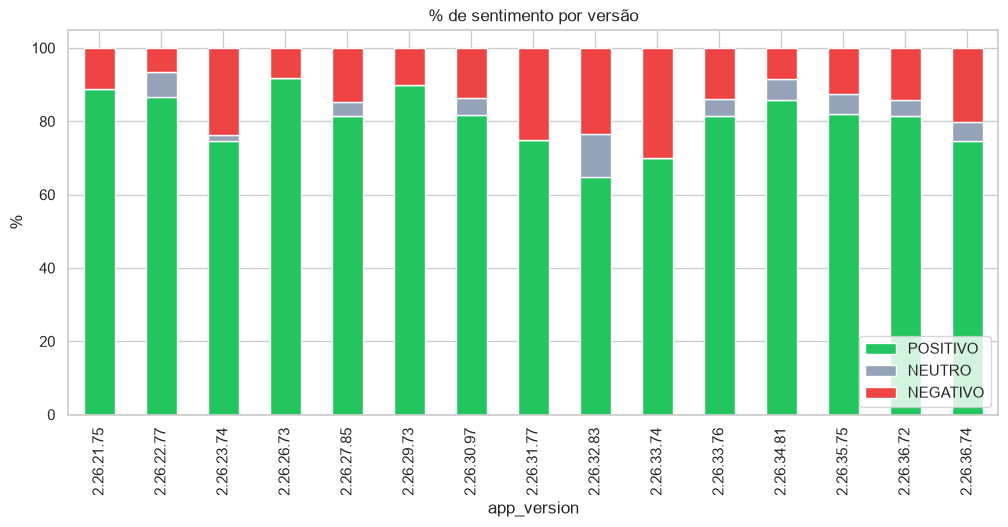

In [8]:
if 'app_version' in df.columns and df['app_version'].notna().any():
    top_versions = df['app_version'].value_counts().head(15).index
    sub = df[df['app_version'].isin(top_versions)]
    ct = pd.crosstab(sub['app_version'], sub['sentiment'], normalize='index') * 100
    ct = ct[['POSITIVO', 'NEUTRO', 'NEGATIVO']]
    ct.plot(kind='bar', stacked=True, color=['#22c55e', '#94a3b8', '#ef4444'])
    plt.title('% de sentimento por versão'); plt.ylabel('%'); plt.legend(loc='lower right'); plt.show()

## 8. Conclusões da EDA

- Volume e distribuição das classes → base para decidir se precisamos de `class_weight='balanced'`.
- Reviews curtos (mediana ≈ palavras) → TF-IDF com bigrams é adequado.
- Versões mais recentes concentram (ou não) mais reclamações → variável útil para o dashboard.
- Termos frequentes distintos por classe indicam boa separabilidade lexical → NB e LogReg devem performar bem.